In [18]:
import os
from PIL import Image
import numpy as np
orig_img_dir = './dataset/OSIC/val/images'

In [ ]:
def get_img(img_base_dir, img_name):
    model_dirs = os.listdir(img_base_dir)
    imgs = {}
    for img_dir in model_dirs:
        img_path = os.path.join(img_base_dir, img_dir, img_name)
        img = Image.open(img_path)
        imgs[img_dir.split('_')[-1]] = np.array(img)
    print(imgs.keys())
    return imgs

# show the images
'''
As the training steps progress, the fake A2B1 images become more realistic (no color) and less A-liked (fibrosis features are less visible).
'''
import matplotlib.pyplot as plt
def show_images(imgs):
    fig, axes = plt.subplots(len(imgs)//5, 5, figsize=(15, 3*(len(imgs)//5)))
    axes = axes.flatten()
    for ax, (name, img) in zip(axes, imgs.items()):
        ax.imshow(img)
        ax.set_title(name)
        ax.axis('off')
    plt.tight_layout()


dict_keys(['0006600.pt', '0006700.pt', '0006800.pt', '0006900.pt', '0007000.pt', '0012800.pt', '0012900.pt', '0013000.pt', '0013100.pt', '0013200.pt', '0022000.pt', '0023000.pt', '0024000.pt', '0025000.pt', '0026000.pt'])


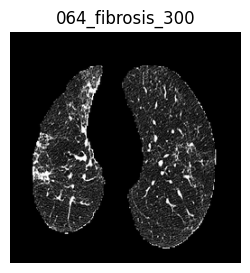

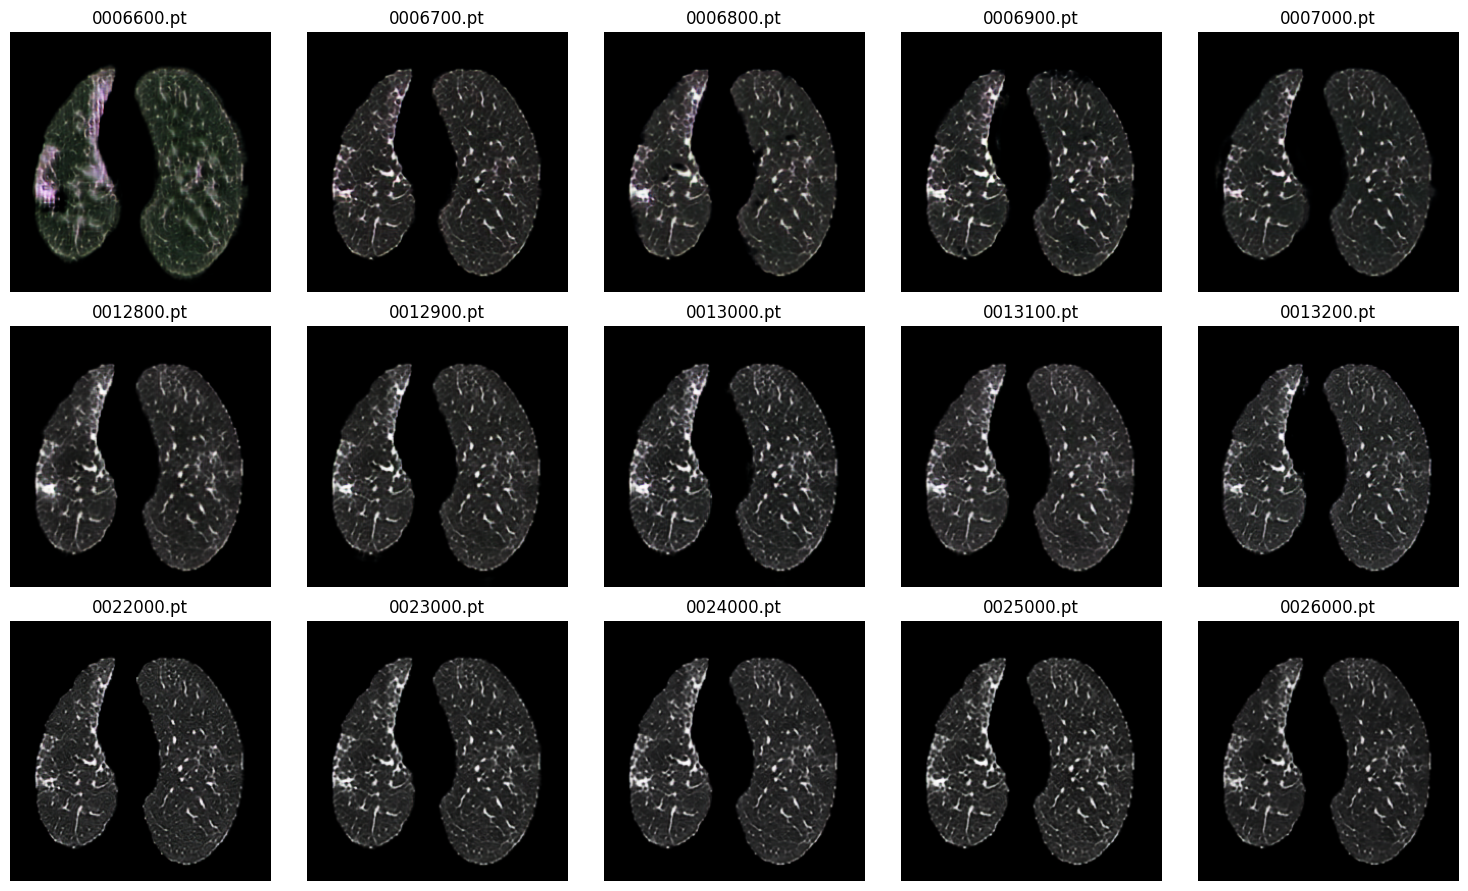

In [29]:
img_base_dir = './results/OSIC/val_folder/fake_A2B1'
img_name = '064_fibrosis_300.png'
imgs = get_img(img_base_dir, img_name)
orig_img = Image.open(os.path.join(orig_img_dir, img_name))
plt.figure(figsize=(3, 3))
plt.imshow(orig_img)
plt.axis('off')
plt.title(img_name.split('.')[0])

show_images(imgs)

dict_keys(['0006600.pt', '0006700.pt', '0006800.pt', '0006900.pt', '0007000.pt', '0012800.pt', '0012900.pt', '0013000.pt', '0013100.pt', '0013200.pt', '0022000.pt', '0023000.pt', '0024000.pt', '0025000.pt', '0026000.pt'])


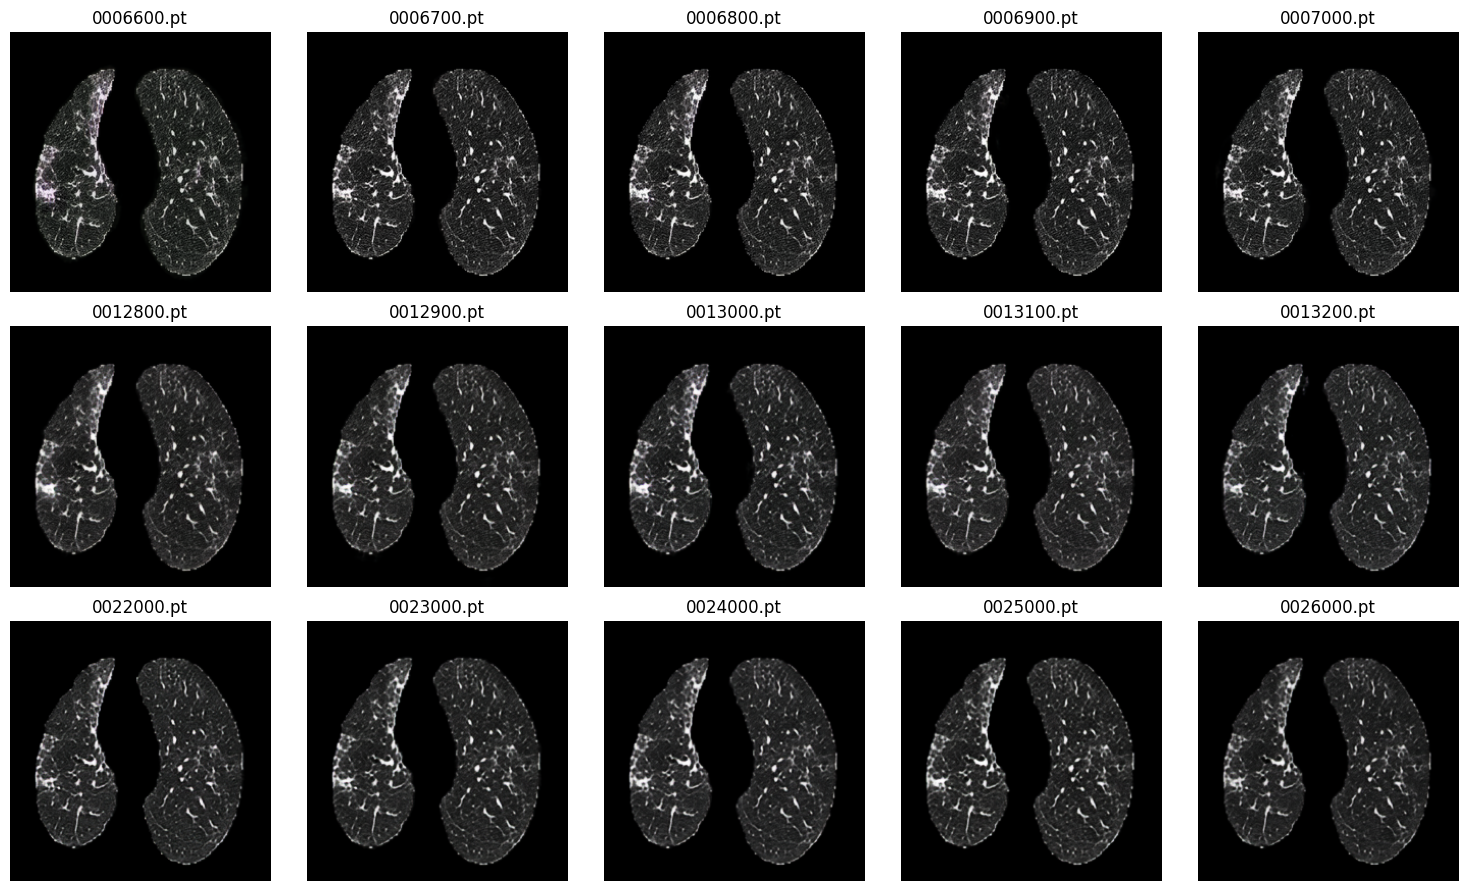

In [16]:
img_base_dir = './results/OSIC/val_folder/fake_A2B_21'
img_name = '064_fibrosis_300.png'
imgs = get_img(img_base_dir, img_name)
show_images(imgs)

In [1]:
# infer process
from CBFNet import CBFNet
import yaml
config_path = "./configs/OSIC_default.yaml"
# Load the YAML file
with open(config_path, 'r') as file:
    args = yaml.unsafe_load(file)

print(args)  # Output: Namespace(phase='train', batch_size=32)
# # debug orig pre-trained model
# args.dataset = 'BraTS'
# args.folder = 'brats_1'

# open session
gan = CBFNet(args)

# build graph
gan.build_model()

Namespace(adv_weight=1, batch_size=1, benchmark_flag=False, cam_weight=1000, ch=54, cycle_weight=10, dataset='OSIC', decay_flag=False, device='cuda', folder='', identity_weight=10, img_ch=3, img_size=256, iteration=7000, light=True, lr=0.0001, n_dis=6, n_res=4, phase='val', print_freq=50, recon_weight=10, result_dir='results', resume=False, save_freq=50, stage=1, weight_decay=2e-05)

##### Information #####
# light :  True
# dataset :  OSIC
# batch_size :  1
# iteration per epoch :  7000

##### Generator #####
# residual blocks :  4

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000


In [2]:
gan.val()

 [*] Load SUCCESS


KeyboardInterrupt: 